#### Notes
Title: The ex vivo human translaminar autonomous system to study spaceflight associated neuro-ocular syndrome pathogenesis (Retina, RT-PCR and electroretinography)
*   Study investogates Spaceflight-Associated Neuro-ocular Syndrome (SANS)
    *   Instead of animal models or astronaut testing, a ex vivo translaminar autonomous system (TAS) under ground-based spaceflight conditions represented the effects of microgravity for human optic nerve anatomy using human tissue samples
    *   Translaminar pressure is generated in the model to simulate the various flow rates within intracranial pressure and intraocular pressure chambers
*   After generating these pressure changes (IOP simulated measurements), inflammatory markers and protein expression readings were collected
*   The study attempts to characterize SANS pathogenesis, optic nerve degredation, and axon function
*   OS = Left eye, OD = Right eye
---
* Assays: rt-PCR, Electrophysiology
* Factors: Pressure gradients (IOP), Optic Nerve Tilt (physiological average is 2 to 3.5 degrees, mechanically kinked to 6 and 10 degree conditions)

# Start

In [1]:
req_file = '../OSD-816_req.txt'
env_file = '../OSD-816_env.yml'
repo_url = 'https://github.com/Sybilade/neuro-ocular-microgravity-expression'
raw_base_url = repo_url.replace("github.com", "raw.githubusercontent.com") + "/main/"
source_url = 'https://osdr.nasa.gov/bio/repo/data/studies/OSD-816'

In [2]:
# Download
import os

if repo_url:

    if not os.path.exists(env_file):
        url = raw_base_url + env_file.replace('../', '')
        print(f"Downloading {env_file} from Github...")
        try:
            urllib.request.urlretrieve(url, env_file)
            print(f"Successfully downloaded {env_file} from Github")
        except Exception as e:
            print(f"Could not download {env_file}: {e}")

    if not os.path.exists(req_file):
        url = raw_base_url + req_file.replace('../', '')
        print(f"Downloading {req_file} from Github...")
        try:
            urllib.request.urlretrieve(url, req_file)
            print(f"Successfully downloaded {req_file} from Github")
        except Exception as e:
            print(f"Could not download {req_file}: {e}")
    
    else:
        print("Dependency files downloaded")
    
# Install dependencies
## If using local, prefer mamba or conda
## mamba env update -f {env_file}
if os.path.exists(req_file):
    print(f"Installing via pip with {req_file}...")
    %pip install -r {req_file}
else:
    print(f"No {req_file} found. Skipping")

Dependency files downloaded
Installing via pip with ../OSD-816_req.txt...
Note: you may need to restart the kernel to use updated packages.


# Libraries

In [18]:
# Dependencies
import sys
import urllib
import awscli
import pandas as pd
import kagglehub
import numpy as np
import zipfile
import os
import duckdb
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [4]:
!aws s3 ls --no-sign-request --recursive --summarize s3://nasa-osdr/OSD-816/version-1/

2026-07-25 17:25:23     300264 OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_15373ODG2.zip
2026-07-25 17:25:22     290058 OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_15373OSG3.zip
2026-07-25 17:25:22     297167 OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_15380ODG4.zip
2026-07-25 17:25:22      98231 OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_15380OSG5.zip
2026-07-25 17:25:22     282621 OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_18004ODG6.zip
2026-07-25 17:25:22     293498 OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_18004OSG1.zip
2026-07-25 17:25:21     292316 OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_20779ODG2.zip
2026-07-25 17:25:21     296651 OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_20779OSG3.zip
2026-07-25 17:25:21     283978 OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_22196O

## Metadata + sample selection

In [5]:
# download metadata into data folder
!aws s3 cp --no-sign-request s3://nasa-osdr/OSD-816/version-1/metadata/OSD-816_metadata_OSD-816-ISA.zip ../data/

zipfile.ZipFile('../data/OSD-816_metadata_OSD-816-ISA.zip').extractall('../data/metadata')

display(os.listdir('../data/metadata'))

Completed 71.2 KiB/71.2 KiB (109.7 KiB/s) with 1 file(s) remaining
download: s3://nasa-osdr/OSD-816/version-1/metadata/OSD-816_metadata_OSD-816-ISA.zip to ..\data\OSD-816_metadata_OSD-816-ISA.zip


['a_OSD-816_electrophysiology_electroretinography_OcuScience.txt',
 'a_OSD-816_transcription-profiling_real-time-pcr_Thermo Fisher Scientific.txt',
 'i_Investigation.txt',
 's_OSD-816.txt']

In [6]:
meta_dir = "../data/metadata/"

df_study = pd.read_csv(os.path.join(meta_dir, "s_OSD-816.txt"), sep="\t")
df_rtpcr = pd.read_csv(os.path.join(meta_dir, "a_OSD-816_transcription-profiling_real-time-pcr_Thermo Fisher Scientific.txt"), sep="\t")
df_epr = pd.read_csv(os.path.join(meta_dir, "a_OSD-816_electrophysiology_electroretinography_OcuScience.txt"), sep="\t")

In [7]:
display(df_study.columns)
display(df_rtpcr.columns)
display(df_epr.columns)

Index(['Source Name', 'Sample Name', 'Characteristics[Organism]',
       'Term Source REF', 'Term Accession Number', 'Characteristics[Sex]',
       'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[age]',
       'Unit', 'Term Source REF.2', 'Term Accession Number.2',
       'Characteristics[Race]', 'Term Source REF.3', 'Term Accession Number.3',
       'Characteristics[Donor Medical History]', 'Comment[Group]',
       'Factor Value[Treatment Pressure (ICP:IOP)]', 'Unit.1',
       'Term Source REF.4', 'Term Accession Number.4',
       'Factor Value[Optic Nerve Tilt]', 'Unit.2', 'Term Source REF.5',
       'Term Accession Number.5', 'Characteristics[Source]',
       'Characteristics[Cell Culture]', 'Term Source REF.6',
       'Term Accession Number.6', 'Characteristics[Material Type]',
       'Term Source REF.7', 'Term Accession Number.7', 'Protocol REF',
       'Parameter Value[Growth Property]', 'Term Source REF.8',
       'Term Accession Number.8', 'Parameter Value[Samp

Index(['Sample Name', 'Characteristics[Has Technical Reps]', 'Term Source REF',
       'Term Accession Number', 'Protocol REF', 'Extract Name',
       'Protocol REF.1', 'Label', 'Term Source REF.1',
       'Term Accession Number.1', 'Protocol REF.2', 'Assay Name',
       'Raw Data File', 'Protocol REF.3',
       'Parameter Value[Derived Data File]'],
      dtype='object')

Index(['Sample Name', 'Protocol REF', 'Parameter Value[Type Of Adaptation]',
       'Parameter Value[Adaptation Duration Prior To Trial Start]', 'Unit',
       'Term Source REF', 'Term Accession Number', 'Protocol REF.1',
       'Parameter Value[Testing Room Temperature]', 'Unit.1',
       'Term Source REF.1', 'Term Accession Number.1',
       'Parameter Value[Describe Any Ambient Light Source(s) Visible To Subject]',
       'Protocol REF.2', 'Parameter Value[ERG Recording Type]',
       'Parameter Value[ERG Device Model And Manufacturer]',
       'Parameter Value[Sequential Or Simultaneous Recording]',
       'Parameter Value[Conductive Solution(s) Used]',
       'Parameter Value[Stimulus Type]', 'Parameter Value[Stimulus Source]',
       'Parameter Value[Stimulus Wavelength]',
       'Parameter Value[Stimulus Strength]', 'Unit.2', 'Term Source REF.2',
       'Term Accession Number.2', 'Parameter Value[Interstimulus Interval]',
       'Unit.3', 'Term Source REF.3', 'Term Accession Num

In [8]:
# Key columns/values from sample data
key_cols = [
    'Sample Name',
    'Characteristics[Sex]',
    'Characteristics[age]',
    'Characteristics[Donor Medical History]',
    'Factor Value[Treatment Pressure (ICP:IOP)]',
    'Factor Value[Optic Nerve Tilt]',
]

def summarize_data(df, cols=None):

    sub_df = df[cols] if cols is not None else df

    summ = pd.DataFrame({
        "Data Type": sub_df.dtypes,
        "Total Count": sub_df.notna().sum(),
        "Non-Null Count": sub_df.notna().sum(),
        "Missing Count": sub_df.isna().sum(),
        "Unique Values": sub_df.nunique()
    })
    return summ.sort_values(by="Missing Count", ascending=False)

display(summarize_data(df_study, cols=key_cols))

,Data Type,Total Count,Non-Null Count,Missing Count,Unique Values
Factor Value[Treatment Pressure (ICP:IOP)],object,24,24,1,4
Factor Value[Optic Nerve Tilt],float64,24,24,1,3
Characteristics[Sex],object,25,25,0,2
Sample Name,object,25,25,0,25
Characteristics[Donor Medical History],object,25,25,0,12
Characteristics[age],int64,25,25,0,12


In [9]:
query = """
SELECT
    "Sample Name",
    "Characteristics[Sex]" AS sex,
    "Characteristics[age]" AS age,
    "Characteristics[Donor Medical history]" AS history,
    "Factor Value[Optic Nerve Tilt]" AS tilt,
    "Factor Value[Treatment Pressure (ICP:IOP)]" AS OP
FROM df_study
WHERE "Characteristics[Material Type]" = 'Right retina'
    AND "Characteristics[Donor Medical History]" NOT IN ('Not Listed', 'Not Available', 'None Listed', 'Not Applicable')
"""

df_sql = duckdb.query(query).df()
display(df_sql)

,Sample Name,sex,age,history,tilt,OP
0,7346_OD,Female,64,"Myocardial infarction, Lung cancer (diagnosed ...",10.0,15:16
1,15373_OD,Female,86,Pancreatic cancer with metastatis to kidneys. ...,0.0,15:16
2,15380_OD,Female,89,"Bowel obstruction, Interstitial lung disease, ...",0.0,21:16
3,18004_OD,Male,82,"Hip Fracture, Stroke, Atrial fibrillation, Chr...",10.0,15:16
4,20779_OD,Male,78,"Pancreatic cancer, Weakness, Hypokalemia",0.0,15:16
5,22536_OD,Male,77,"Leukemia, thrombocytopenia, transfusions (O-ne...",10.0,15:16
6,32115_OD,Male,77,Brain cancer. Past Medical History: Atrial fib...,0.0,15:16
7,34085_OD,Male,87,"End-Stage Liver Disease, Abdominal pain second...",0.0,21:16
8,827_OD,Male,67,Acute cardiac crisis secondary to Hypertension...,0.0,12:16


Selecting:
*   15373_OD
*   15380_OD
*   20779_OD
*   34085_OD

In [10]:
samples_816 = ['15373_OD', '15380_OD', '20779_OD', '34085_OD']

df_cohort = df_study[df_study['Sample Name'].isin(samples_816)][key_cols].copy()

display(df_cohort)

,Sample Name,Characteristics[Sex],Characteristics[age],Characteristics[Donor Medical History],Factor Value[Treatment Pressure (ICP:IOP)],Factor Value[Optic Nerve Tilt]
2,15373_OD,Female,86,Pancreatic cancer with metastatis to kidneys. ...,15:16,0.0
4,15380_OD,Female,89,"Bowel obstruction, Interstitial lung disease, ...",21:16,0.0
8,20779_OD,Male,78,"Pancreatic cancer, Weakness, Hypokalemia",15:16,0.0
16,34085_OD,Male,87,"End-Stage Liver Disease, Abdominal pain second...",21:16,0.0


Conditions investigated:
*   '15:16' Elevated ICP; not as severe as '21:16' seen in spaceflight but possible early physiological effect from microgravity
*   '0 degree' optic nerve tilt; 10 degrees mimic SANS as pressure pushes the eye forward, titling the optic nerve from its baseline 0 degree stature

## Download sample cohort data

In [11]:
# Processed files from repo
!aws s3 cp --no-sign-request "s3://nasa-osdr/OSD-816/version-1/RT-PCR/GLDS-700_RT-PCR_NASA_QPCR.xlsx" ../data/processed/
!aws s3 cp --no-sign-request "s3://nasa-osdr/OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_Sample groups Fig1.xlsx" ../data/processed/

Completed 41.8 KiB/41.8 KiB (81.0 KiB/s) with 1 file(s) remaining
download: s3://nasa-osdr/OSD-816/version-1/RT-PCR/GLDS-700_RT-PCR_NASA_QPCR.xlsx to ..\data\processed\GLDS-700_RT-PCR_NASA_QPCR.xlsx
Completed 9.5 KiB/9.5 KiB (22.6 KiB/s) with 1 file(s) remaining
download: s3://nasa-osdr/OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_Sample groups Fig1.xlsx to ..\data\processed\LSDS-136_Electroretinography_Sample groups Fig1.xlsx


In [12]:
excel_qpcr = pd.ExcelFile('..\data\processed\GLDS-700_RT-PCR_NASA_QPCR.xlsx')
print('RT-PCR Sheet Names:', excel_qpcr.sheet_names)

excel_erg = pd.ExcelFile('..\data\processed\LSDS-136_Electroretinography_Sample groups Fig1.xlsx')
print('ERG Sheet Names:', excel_erg.sheet_names)

RT-PCR Sheet Names: ['42991 OD', '37350 OD 37350 OS', '39574 OS 41204 OS', '00827 OD 00827 OS', 'Run1 ']
ERG Sheet Names: ['Sheet1']


In [13]:
!aws s3 cp --no-sign-request "s3://nasa-osdr/OSD-816/version-1/RT-PCR/GLDS-700_RT-PCR_Analysis_qPCR.xlsx" ../data/processed/

excel_qpcr2 = pd.ExcelFile('../data/processed/GLDS-700_RT-PCR_Analysis_qPCR.xlsx')
print('RT-PCR Sheet Names:', excel_qpcr2.sheet_names)

Completed 106.8 KiB/106.8 KiB (164.9 KiB/s) with 1 file(s) remaining
download: s3://nasa-osdr/OSD-816/version-1/RT-PCR/GLDS-700_RT-PCR_Analysis_qPCR.xlsx to ..\data\processed\GLDS-700_RT-PCR_Analysis_qPCR.xlsx
RT-PCR Sheet Names: ['07346 OU Run1 G6OD G1OS', '15373 OU Run1 G2OD G3OS', '15380 OU Run1 G4OD G5OS', 'Run 1 Analysis', '18004 OU Run2 G6OD G1OS', '20779 OU Run2 G2OD G3OS', '22196 OU Run2 G4OD G5OS', 'Run 2 Analysis', '22536 OU Run3 G6OD G1OS', '32115 OU Run3 G2OD G3OS', '34085 OU Run3 G4OD G5OS ', 'Run 3 Analysis', 'Final Analysis']


investigating the final analysis sheet

In [14]:
df_qpcr_final = pd.read_excel('../data/processed/GLDS-700_RT-PCR_Analysis_qPCR.xlsx', sheet_name='Final Analysis')
print("qPCR Final Analysis Columns/Shape:", df_qpcr_final.shape)
display(df_qpcr_final.head(10))

qPCR Final Analysis Columns/Shape: (48, 23)


,Unnamed: 0,Fold Value - 2^(-deltaCq),Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,0,07346 OD Group 6,07346 OS Group 1,15373 OD Group 2,15373 OS Group 3,15380 OD Group 4,15380 OS Group 5,NaN,0,18004 OD Group 6,...,22196 OD Group 4,22196 OS Group 5,NaN,0,22536 OD Group 6,22536 OS Group 1,32115 OD Group 2,32115 OS Group 3,34085 OD Group 4,34085 OS Group 5
1,GAPDH,0,0,0,0,0,0,NaN,GAPDH,0,...,0,0,NaN,GAPDH,0,0,0,0,0,0
2,BCL2,NaN,NaN,NaN,0.001717,NaN,NaN,NaN,BCL2,NaN,...,NaN,NaN,NaN,BCL2,NaN,NaN,NaN,NaN,NaN,NaN
3,BAX,0.00472,NaN,0.007577,0.008656,0.19365,NaN,NaN,BAX,NaN,...,0.002928,0.005448,NaN,BAX,0.012835,0.003833,0.005292,0.003242,0.013031,0.006514
4,CASP3,0.009682,NaN,0.002703,0.003046,NaN,0.007037,NaN,CASP3,NaN,...,NaN,NaN,NaN,CASP3,0.001205,0.001491,NaN,NaN,0.005392,0.005828
5,CASP7,0.004681,NaN,0.00262,0.004031,NaN,NaN,NaN,CASP7,NaN,...,NaN,NaN,NaN,CASP7,NaN,NaN,NaN,NaN,0.00522,0.004261
6,CASP8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CASP8,NaN,...,NaN,NaN,NaN,CASP8,0.000835,NaN,NaN,NaN,NaN,NaN
7,TLR4,NaN,NaN,NaN,0.001546,0.066877,NaN,NaN,TLR4,NaN,...,NaN,0.001222,NaN,TLR4,NaN,0.001327,NaN,NaN,NaN,0.004141
8,TNF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TNF,NaN,...,NaN,NaN,NaN,TNF,NaN,NaN,NaN,NaN,NaN,NaN
9,GFAP,0.663896,0.068871,0.813698,1.29881,1.753163,0.116391,NaN,GFAP,0.261265,...,0.358804,0.600059,NaN,GFAP,0.124635,0.101921,0.084615,0.093453,0.283754,1.562294


Fold value indicates gene expression. Cq = cycle count, ie how many cycles of RNA needed to be copied in order to hit detection threshold. the fold value being 2 to the negative delta Cq means this relationship was reverted to where a larger number indicates higher expression and vice versa

In [15]:
df_qpcr_clean = pd.read_excel('../data/processed/GLDS-700_RT-PCR_Analysis_qPCR.xlsx',
    sheet_name='Final Analysis',
    header=1 # Make the second row the header
)

df_qpcr_clean.rename(columns={df_qpcr_clean.columns[0]: 'Gene'}, inplace=True) # Add gene row label

df_qpcr_clean = df_qpcr_clean.dropna(subset=['Gene'])
df_qpcr_clean = df_qpcr_clean[df_qpcr_clean['Gene'] != 0]


target_cols = {
    '15373 OD Group 2': '15373_OD (F, 15:16 [Control])',
    '15380 OD Group 4': '15380_OD (F, 21:16)',
    '20779 OD Group 2': '20779_OD (M, 15:16 [Control])',
    '34085 OD Group 4': '34085_OD (M, 21:16)'
}

# Filter to just samples we need
df_cohort_genes = df_qpcr_clean[['Gene'] + list(target_cols.keys())].copy()

df_cohort_genes.rename(columns=target_cols, inplace=True)
df_cohort_genes.reset_index(drop=True, inplace=True)

display(df_cohort_genes)

,Gene,"15373_OD (F, 15:16 [Control])","15380_OD (F, 21:16)","20779_OD (M, 15:16 [Control])","34085_OD (M, 21:16)"
0,GAPDH,0,0,0,0
1,BCL2,NaN,NaN,0.000404,NaN
2,BAX,0.007577,0.19365,0.006896,0.013031
3,CASP3,0.002703,NaN,0.001158,0.005392
4,CASP7,0.00262,NaN,0.001252,0.00522
5,CASP8,NaN,NaN,NaN,NaN
6,TLR4,NaN,0.066877,0.000869,NaN
7,TNF,NaN,NaN,NaN,NaN
8,GFAP,0.813698,1.753163,0.591581,0.283754
9,GSS,0.002734,0.091499,0.002466,0.011781


# Visualizations (Gene Expression)

In [23]:
# 1. Explicitly calculate the Row Z-score for each gene:
# Formula: (Value - Gene Row Mean) / Gene Row Standard Deviation
df_zscore = df_heat_active.apply(
    lambda row: (row - row.mean()) / row.std() if row.std() > 0 else row - row.mean(), 
    axis=1
)

# 2. Display the actual Z-score table
display(df_zscore.round(2).head())

,"15373_OD (F, 15:16 [Control])","15380_OD (F, 21:16)","20779_OD (M, 15:16 [Control])","34085_OD (M, 21:16)"
Gene,,,,
BCL2,-0.50,-0.50,1.50,-0.50
BAX,-0.52,1.50,-0.52,-0.46
CASP3,0.17,-0.99,-0.50,1.32
CASP7,0.15,-1.02,-0.46,1.32
TLR4,-0.51,1.50,-0.48,-0.51


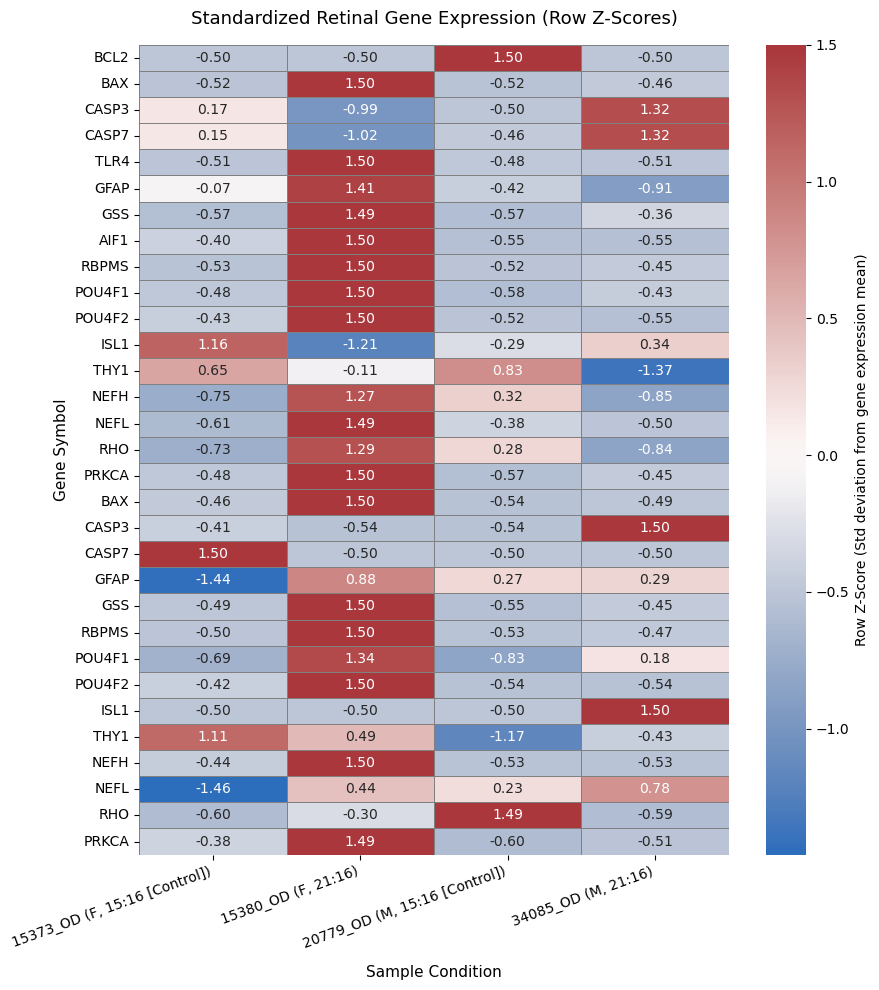

In [25]:
plt.figure(figsize=(9, 10))

sns.heatmap(
    df_zscore,
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Row Z-Score (Std deviation from gene expression mean)'}
)

plt.title('Standardized Retinal Gene Expression (Row Z-Scores)', fontsize=13, pad=15)
plt.xlabel('Sample Condition', fontsize=11, labelpad=10)
plt.ylabel('Gene Symbol', fontsize=11)
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## Feature Prioritization

In [ ]:
# from view of table, there were duplicate runs, this confirms
df_cohort_genes['Gene'].value_counts()

Gene
GAPDH     2
BCL2      2
BAX       2
CASP3     2
CASP7     2
CASP8     2
TLR4      2
TNF       2
GFAP      2
GSS       2
AIF1      2
RBPMS     2
POU4F1    2
POU4F2    2
POU4F3    2
ISL1      2
THY1      2
NEFH      2
NEFL      2
RHO       2
PRKCA     2
STX1A     2
Name: count, dtype: int64

In [33]:
def rank_candidate_genes(df):
    """
    Ranks genes based on pressure effect size (Log2FC), 
    variance across donors, and sex-specific divergence.
    """
    f_ctrl = '15373_OD (F, 15:16 [Control])'
    f_high = '15380_OD (F, 21:16)'
    m_ctrl = '20779_OD (M, 15:16 [Control])'
    m_high = '34085_OD (M, 21:16)'
    
    cols = [f_ctrl, f_high, m_ctrl, m_high]

    # create table used for statistical inferences
    data = df[['Gene'] + cols].copy()
    
    '''
    Force all numerical columns to float64 (coercing any text/artifacts to NaN)
    This occured due to pandas importing the excel file as a generic object however numpy log
    can only work on float type
    errors='coerce' prevents non-numeric text from attempting conversion to avoid crash
    '''
    for c in cols:
        data[c] = pd.to_numeric(data[c], errors='coerce')

    data[cols] = data[cols].fillna(0.0)
        
    # Group by gene and take mean of runs
    data = data.groupby('Gene', as_index=False)[cols].mean()
    
    # means
    ctrl_mean = (data[f_ctrl] + data[m_ctrl]) / 2.0
    high_mean = (data[f_high] + data[m_high]) / 2.0
    
    # Log2 Fold-Change between pressure groups
    ratio = ((high_mean) + 1e-5 / (ctrl_mean) + 1e-5).astype(float)
    log2_fc = np.log2(ratio)
    
    # difference in expression between sex
    f_diff = data[f_high] - data[f_ctrl]
    m_diff = data[m_high] - data[m_ctrl]
    sex_divergence = (f_diff - m_diff).abs()
    
    # Variance
    gene_variance = data[cols].std(axis=1)
    
    # Gene priority for invstigation: Effect Size * Variance
    priority_score = log2_fc.abs() * (gene_variance) + 1e-5
    
    # 8. Build Summary Ranking Table
    ranking_df = pd.DataFrame({
        'Gene': data['Gene'],
        'Baseline Avg': ctrl_mean.round(4),
        'High Press Avg': high_mean.round(4),
        'Log2_FC (Pressure)': log2_fc.round(2),
        'Sex Divergence': sex_divergence.round(4),
        'Variance (Std)': gene_variance.round(4),
        'Priority Score': priority_score.round(3)
    })
    
    return ranking_df.sort_values(by='Priority Score', ascending=False).reset_index(drop=True)

# Run on your cohort
df_ranked = rank_candidate_genes(df_cohort_genes)
display(df_ranked.head(10))

,Gene,Baseline Avg,High Press Avg,Log2_FC (Pressure),Sex Divergence,Variance (Std),Priority Score
0,BAX,0.4049,10.5619,3.40,19.2926,10.0896,34.313
1,RBPMS,0.2444,6.3448,2.67,11.4855,5.9186,15.777
2,PRKCA,0.3823,3.7281,1.90,6.0971,3.4153,6.484
3,GSS,0.0978,3.4114,1.77,5.9927,3.1692,5.611
4,NEFH,0.1557,3.1830,1.67,6.0882,3.1340,5.235
5,POU4F2,0.1914,3.1347,1.65,5.8874,3.0761,5.071
6,RHO,5.9491,2.0858,1.06,10.5563,4.4004,4.667
7,POU4F1,0.1283,3.0229,1.60,1.9851,1.9080,3.045
8,NEFL,1.4481,3.1500,1.66,2.0187,1.3366,2.213
9,CASP7,0.1409,0.0013,-9.49,0.2831,0.1400,1.329


In [29]:
# Genes with large positive Log2FC
df_ranked.sort_values(by='Log2_FC (Pressure)', ascending=False).head(5)

,Gene,Baseline Avg,High Press Avg,Log2_FC (Pressure),Sex Divergence,Variance (Std),Priority Score
13,TLR4,0.0004,0.0334,6.23,0.0677,0.0333,0.208
9,ISL1,0.0057,0.3946,6.10,0.7942,0.3927,2.396
2,GSS,0.0984,3.4114,5.12,5.9939,3.1689,16.210
0,BAX,0.4066,10.5619,4.70,19.2960,10.0890,47.408
1,RBPMS,0.2444,6.3448,4.70,11.4855,5.9186,27.808


In [30]:
# Genes where males and females reacted most differently
df_ranked.sort_values(by='Sex Divergence', ascending=False).head(5)

,Gene,Baseline Avg,High Press Avg,Log2_FC (Pressure),Sex Divergence,Variance (Std),Priority Score
0,BAX,0.4066,10.5619,4.70,19.2960,10.0890,47.408
1,RBPMS,0.2444,6.3448,4.70,11.4855,5.9186,27.808
7,RHO,5.9491,2.0858,-1.51,10.5563,4.4004,6.654
3,NEFH,0.1640,3.1830,4.28,6.1050,3.1311,13.396
5,PRKCA,0.3834,3.7281,3.28,6.0994,3.4149,11.205


# Electrophysiology Data

In [34]:
# 1. Load the ERG dataset
erg_path = '../data/processed/LSDS-136_Electroretinography_Sample groups Fig1.xlsx'
df_erg_raw = pd.read_excel(erg_path, sheet_name='Sheet1')

# 2. Inspect dimensions and structure
print("ERG Table Shape:", df_erg_raw.shape)
display(df_erg_raw.head(15))

ERG Table Shape: (18, 8)


,Subject #,Eye,Gender,Age,Race,Group,Days on System (incl. setup date),Diagnosis
0,7346,OD,Female,64,Caucasian,6,14,"Myocardial infarction, Lung cancer (dx 2019, a..."
1,7346,OS,Female,64,Caucasian,1,14,NaN
2,15373,OD,Female,86,Caucasian,2,14,"Pancreatic cancer with mets to kidneys. HTN, ..."
3,15373,OS,Female,86,Caucasian,3,14,NaN
4,15380,OD,Female,89,Caucasian,4,14,"Bowel obstruction. Interstitial lung disease,..."
5,15380,OS,Female,89,Caucasian,5,14,NaN
6,18004,OD,Male,82,Caucasian,6,13,"Hip Fracture, Stroke, AFib, COPD, HTN, Kidney ..."
7,18004,OS,Male,82,Caucasian,1,13,NaN
8,20779,OD,Male,78,Caucasian,2,12,"Pancreatic cancer, Weakness, Hypokalemia"
9,20779,OS,Male,78,Caucasian,3,12,NaN


In [35]:
# Filter sample group to cohort
cohort_subjects = [15373, 15380, 20779, 34085]
# Electroretinography
df_erg_cohort = df_erg_raw[
    (df_erg_raw['Subject #'].isin(cohort_subjects)) & 
    (df_erg_raw['Eye'] == 'OD')
].copy()

# Match previous sample format
df_erg_cohort['Sample Name'] = df_erg_cohort['Subject #'].astype(str) + '_' + df_erg_cohort['Eye']

display(df_erg_cohort[['Sample Name', 'Gender', 'Age', 'Group', 'Diagnosis']])

# erg_files only includes the sample cohort and following info we want
erg_files = df_epr[df_epr['Sample Name'].isin(df_erg_cohort['Sample Name'])][
    ['Sample Name', 'Parameter Value[ERG Recording Type]', 
    'Parameter Value[Waveform Components]', 'Raw Data File']
]
display(erg_files)

,Sample Name,Gender,Age,Group,Diagnosis
2,15373_OD,Female,86,2,"Pancreatic cancer with mets to kidneys. HTN, ..."
4,15380_OD,Female,89,4,"Bowel obstruction. Interstitial lung disease,..."
8,20779_OD,Male,78,2,"Pancreatic cancer, Weakness, Hypokalemia"
16,34085_OD,Male,87,4,"ESLD, Abdominal pain 2/2 TURP on 8/14. COVID N..."


,Sample Name,Parameter Value[ERG Recording Type],Parameter Value[Waveform Components],Raw Data File
2,15373_OD,Scotopic,Amplitudes measured (baseline to positive peak...,LSDS-136_Electroretinography_15373ODG2.zip
4,15380_OD,Scotopic,Amplitudes measured (baseline to positive peak...,LSDS-136_Electroretinography_15380ODG4.zip
8,20779_OD,Scotopic,Amplitudes measured (baseline to positive peak...,LSDS-136_Electroretinography_20779ODG2.zip
16,34085_OD,Scotopic,Amplitudes measured (baseline to positive peak...,LSDS-136_Electroretinography_34085ODG4.zip


Scotopic: Human retina models were tested under total darkness
*   Tests rod receptors which are responsible for light sensitivity, more so than cones
Amplitudes measured (baseline to peak): B-Wave nerve measurements
*   Retinal transmission of electrical signal to optic nerve
*   Higher amplitude = firing; lower amplitude = lacking transmission power

In [38]:
# Download raw ERG files for cohort
for raw_zip in erg_files['Raw Data File']:
    s3_url = f"s3://nasa-osdr/OSD-816/version-1/Electroretinography/{raw_zip}"
    !aws s3 cp --no-sign-request "{s3_url}" ../data/raw/

# Inspection
sample_zip = zipfile.ZipFile('../data/raw/LSDS-136_Electroretinography_15373ODG2.zip')
print("Files inside 15373ODG2.zip:")
for f in sample_zip.namelist()[:10]:
    print(" -", f)

Completed 256.0 KiB/293.2 KiB (241.1 KiB/s) with 1 file(s) remaining
Completed 293.2 KiB/293.2 KiB (252.1 KiB/s) with 1 file(s) remaining
download: s3://nasa-osdr/OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_15373ODG2.zip to ..\data\raw\LSDS-136_Electroretinography_15373ODG2.zip
Completed 256.0 KiB/290.2 KiB (364.2 KiB/s) with 1 file(s) remaining
Completed 290.2 KiB/290.2 KiB (411.6 KiB/s) with 1 file(s) remaining
download: s3://nasa-osdr/OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_15380ODG4.zip to ..\data\raw\LSDS-136_Electroretinography_15380ODG4.zip
Completed 256.0 KiB/285.5 KiB (401.9 KiB/s) with 1 file(s) remaining
Completed 285.5 KiB/285.5 KiB (447.5 KiB/s) with 1 file(s) remaining
download: s3://nasa-osdr/OSD-816/version-1/Electroretinography/LSDS-136_Electroretinography_20779ODG2.zip to ..\data\raw\LSDS-136_Electroretinography_20779ODG2.zip
Completed 256.0 KiB/288.7 KiB (316.5 KiB/s) with 1 file(s) remaining
Completed 288.7 KiB/288.7

.spl file cannot be read however prism file was found to use (software used by experimenters for quick and clean readings)

In [41]:
# ERG submitted data
display(df_epr['Parameter Value[Submitted Analysis Files]'])

0     OSD-816_sup_Prism Files.zip
1     OSD-816_sup_Prism Files.zip
2     OSD-816_sup_Prism Files.zip
3     OSD-816_sup_Prism Files.zip
4     OSD-816_sup_Prism Files.zip
5     OSD-816_sup_Prism Files.zip
6     OSD-816_sup_Prism Files.zip
7     OSD-816_sup_Prism Files.zip
8     OSD-816_sup_Prism Files.zip
9     OSD-816_sup_Prism Files.zip
10    OSD-816_sup_Prism Files.zip
11    OSD-816_sup_Prism Files.zip
12    OSD-816_sup_Prism Files.zip
13    OSD-816_sup_Prism Files.zip
14    OSD-816_sup_Prism Files.zip
15    OSD-816_sup_Prism Files.zip
16    OSD-816_sup_Prism Files.zip
17    OSD-816_sup_Prism Files.zip
Name: Parameter Value[Submitted Analysis Files], dtype: object

In [ ]:
# Download
!aws s3 cp --no-sign-request "s3://nasa-osdr/OSD-816/version-1/sup/OSD-816_sup_Prism Files.zip" ../data/processed/

#Inspect
prism_zip = zipfile.ZipFile('../data/processed/OSD-816_sup_Prism Files.zip')
print("Prism Files in Archive:")
for f in prism_zip.namelist():
    if not f.startswith('__MACOSX'):
        print(" -", f)

Completed 256.0 KiB/1.2 MiB (305.9 KiB/s) with 1 file(s) remaining
Completed 512.0 KiB/1.2 MiB (537.4 KiB/s) with 1 file(s) remaining
Completed 768.0 KiB/1.2 MiB (804.4 KiB/s) with 1 file(s) remaining
Completed 1.0 MiB/1.2 MiB (932.7 KiB/s) with 1 file(s) remaining  
Completed 1.2 MiB/1.2 MiB (1.1 MiB/s) with 1 file(s) remaining    
download: s3://nasa-osdr/OSD-816/version-1/sup/OSD-816_sup_Prism Files.zip to ..\data\processed\OSD-816_sup_Prism Files.zip
Prism Files in Archive:
 - Prism Files/
 - Prism Files/.DS_Store
 - Prism Files/TaqMan Array Analysis.pzf
 - Prism Files/05_09_2022_ERG_microgravity.xlsx
 - Prism Files/05_09_2022_ERG_microgravity.pzfx


*   05_09_2022_ERG_microgravity.xlsx = The processed file needed
*   05_09_2022_ERG_microgravity.pzfx = Prism file paired to Excel sheet
*   TaqMan Array Analysis.pzf = For gene data

In [ ]:
# Extract
prism_zip.extract('Prism Files/05_09_2022_ERG_microgravity.xlsx', path='../data/processed/')

# Inspect
erg_excel_path = '../data/processed/Prism Files/05_09_2022_ERG_microgravity.xlsx'
xl_erg = pd.ExcelFile(erg_excel_path)
print("ERG Sheet Names:", xl_erg.sheet_names)

# Preview first sheet
df_erg_summary = pd.read_excel(erg_excel_path, sheet_name=xl_erg.sheet_names[0])
print("Shape of first sheet:", df_erg_summary.shape)
display(df_erg_summary.head(10))

ERG Sheet Names: ['7346ODG6 _Group1', '7346OSG1-Group 2', '32115ODG2-Group 3', '20779OSG3-Group 4', '34085ODG4-Group 5', '34085OSG5- Group 6', 'control 0440 os retina', 'control 0551os retina']
Shape of first sheet: (265, 6)


,Unnamed: 0,Hours_0,Hours_1,_0,_1,_2
0,0,0.0,0.0,2.26,NaN,NaN
1,1,0.8,0.8,2.07,NaN,NaN
2,2,1.5,1.5,3.34,NaN,NaN
3,3,2.3,2.3,3.63,NaN,NaN
4,4,3.0,3.0,2.32,NaN,NaN
5,5,3.8,3.8,3.10,NaN,NaN
6,6,4.5,4.5,2.71,NaN,NaN
7,7,5.3,5.3,2.45,NaN,NaN
8,8,6.0,6.0,3.61,NaN,NaN
9,9,6.8,6.8,2.51,NaN,NaN


In [ ]:
# Sheets matching our cohort donors plus the Group 2 baseline control
target_sheets = [
    # Ignore '-Group #' as this is Prism labelling, actual group label is 'G2' or 'G4'
    '32115ODG2-Group 3',   # Group 2: Baseline Control (0° tilt, 15:16)
    '34085ODG4-Group 5',   # Group 4: SANS High Pressure (0° tilt, 21:16) - Cohort
    '20779OSG3-Group 4',   # Group 3: Moderate Pressure (6° tilt, 15:16) - Cohort
    '34085OSG5- Group 6'   # Group 5: SANS High Pressure (6° tilt, 21:16) - Cohort
]

# Clean data
cohort_erg = {}
for sheet in target_sheets:
    df_raw = pd.read_excel(erg_excel_path, sheet_name=sheet)
    df_clean = df_raw[['Hours_0', '_0']].dropna().reset_index(drop=True)
    df_clean.columns = ['Hours', 'Amplitude_uV']
    cohort_erg[sheet] = df_clean

summary_rows = []
for sheet_name, df_data in cohort_erg.items():
    start_amp = df_data['Amplitude_uV'].iloc[0]
    final_amp = df_data['Amplitude_uV'].iloc[-1]
    peak_amp = df_data['Amplitude_uV'].max()
    retention = (final_amp / (start_amp + 1e-5)) * 100
    
    summary_rows.append({
        'Sheet Name': sheet_name,
        'Total Hours': df_data['Hours'].max(),
        'Start Amp (μV)': round(start_amp, 2),
        'Peak Amp (μV)': round(peak_amp, 2),
        'Final Amp (μV)': round(final_amp, 2),
        'Signal Retention (%)': round(retention, 1)
    })

df_erg_summary_table = pd.DataFrame(summary_rows)
display(df_erg_summary_table)

,Sheet Name,Total Hours,Start Amp (μV),Peak Amp (μV),Final Amp (μV),Signal Retention (%)
0,32115ODG2-Group 3,199.2,-18.65,133.36,-10.20,54.7
1,34085ODG4-Group 5,199.2,8.51,17.10,7.64,89.8
2,20779OSG3-Group 4,199.2,49.57,334.20,33.59,67.8
3,34085OSG5- Group 6,199.2,-599.73,318.90,-593.54,99.0


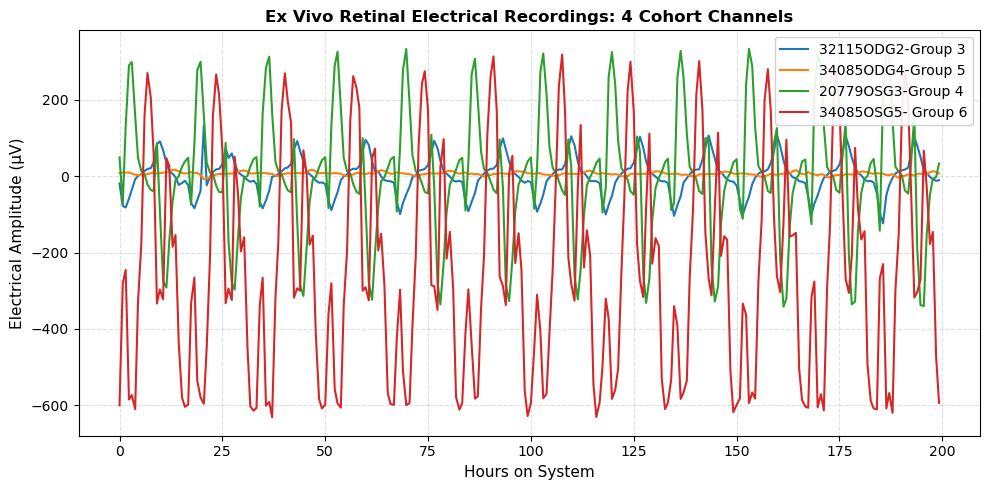

In [54]:
# Single clean plot for all 4 cohort channels
plt.figure(figsize=(10, 5))

for sheet, df in cohort_erg.items():
    plt.plot(df['Hours'], df['Amplitude_uV'], label=sheet, lw=1.5)

plt.title("Ex Vivo Retinal Electrical Recordings: 4 Cohort Channels", fontsize=12, fontweight='bold')
plt.xlabel("Hours on System", fontsize=11)
plt.ylabel("Electrical Amplitude (μV)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

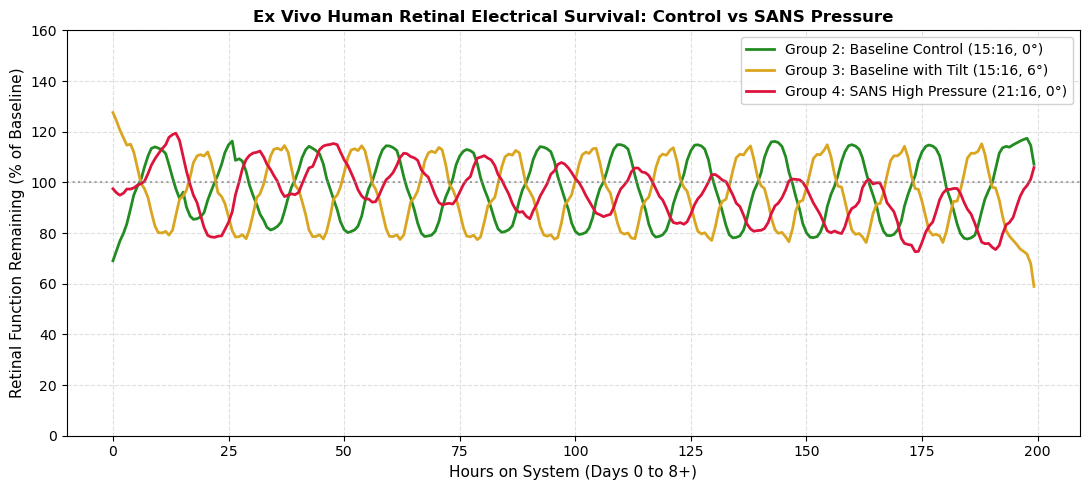

In [59]:
plt.figure(figsize=(11, 5))

comparable_sheets = {
    '32115ODG2-Group 3': ('Group 2: Baseline Control (15:16, 0°)', 'forestgreen'),
    '20779OSG3-Group 4': ('Group 3: Baseline with Tilt (15:16, 6°)', 'goldenrod'),
    '34085ODG4-Group 5': ('Group 4: SANS High Pressure (21:16, 0°)', 'crimson')
}

# Structured for 'sheet : (label_name, line_color)' from above
for sheet, (label_name, line_color) in comparable_sheets.items():
    df = cohort_erg[sheet].copy()
    
    # Shift by minimum so baseline trough rests at 0 μV due to negative DC drifts
    amp_shifted = df['Amplitude_uV'] - df['Amplitude_uV'].min()
    
    # Baseline is average shifted signal in the first 12 hours
    ## Avoids some of the early signals before model stabilizes to repeated signals
    baseline = amp_shifted[df['Hours'] <= 12].mean()
    
    # Normalize to % of baseline (all channels start around 100%)
    ## 100% = no change from baseline for sample
    df['Norm_Amp'] = (amp_shifted / baseline) * 100
    
    # Smooth with a 15-point rolling window (~12 hours) to remove pump flush spikes
    ## Rolling window reduces noise and reduce impact of outliers
    ### min_periods handles edges without 15 measurements, just average the points that are there
    ### (possible cause of the deviation from pattern at the end)
    df['Smooth_Norm'] = df['Norm_Amp'].rolling(window=15, min_periods=1, center=True).mean()
    
    plt.plot(df['Hours'], df['Smooth_Norm'], label=label_name, color=line_color, lw=2.0)

plt.axhline(100, color='gray', linestyle=':', alpha=0.7)
plt.title("Ex Vivo Human Retinal Electrical Survival: Control vs SANS Pressure", fontsize=12, fontweight='bold')
plt.xlabel("Hours on System (Days 0 to 8+)", fontsize=11)
plt.ylabel("Retinal Function Remaining (% of Baseline)", fontsize=11)
plt.ylim(0, 160)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

SANS physiological model shows a gradual decrease in signal propogation
*   Due to long spaceflight condition exposure, astronauts may experience damage to the optic nerve

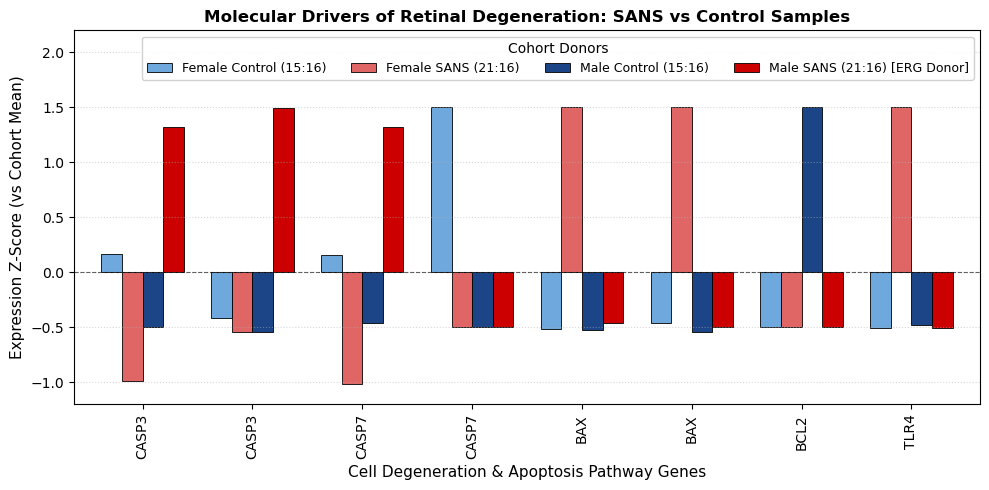

In [66]:
# key molecular signals of cell degeneration & apoptosis
key_genes = ['CASP3', 'CASP7', 'BAX', 'BCL2', 'TLR4']

# cohort labels
sample_labels = {
    '15373_OD (F, 15:16 [Control])': 'Female Control (15:16)',
    '15380_OD (F, 21:16)': 'Female SANS (21:16)',
    '20779_OD (M, 15:16 [Control])': 'Male Control (15:16)',
    '34085_OD (M, 21:16)': 'Male SANS (21:16) [ERG Donor]'
}

# Pull data and label
plot_df = df_zscore.loc[key_genes].rename(columns=sample_labels)

# Controls in blue, SANS in red
fig, ax = plt.subplots(figsize=(10, 5))

plot_df.plot(
    kind='bar', 
    ax=ax, 
    width=0.75, 
    color=['#6fa8dc', '#e06666', '#1c4587', '#cc0000'],
    edgecolor='black', 
    linewidth=0.6
)

ax.set_title('Molecular Drivers of Retinal Degeneration: SANS vs Control Samples', fontsize=12, fontweight='bold')
ax.set_xlabel('Cell Degeneration & Apoptosis Pathway Genes', fontsize=11)
ax.set_ylabel('Expression Z-Score (vs Cohort Mean)', fontsize=11)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend(title='Cohort Donors', frameon=True, facecolor='white', framealpha=0.9, fontsize=9, ncol=4)
ax.set_ylim(-1.2, 2.2)
ax.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Male SANS Donor exhibited upregulated genes responsible for initiating cell death with slight downregulatioin of BCL2 responsible for cell proliferation
*   Casp3 and Casp7: responsible for irreversible proteolytic cleavage of structural cytoskeletal proteins and DNA repair machinery in retinal ganglion cells (RGCs) and photoreceptors. This molecular dismantling directly accounts for the progressive loss of retinal electrical conductivity (falling from 100% to ~45–50% baseline retention) tracked during microgravity simulation

Male Control donor exhibited hightened expression of BCL2 and downregulation of apoptopic genes possibly indicating continued cell survival in microgravity environment
*   Control group exhbited no changes in signal retention during microgravity conditions

Female SANS Donor exhibited hightened BAX expression which follows a different apoptosis pathway compared to the capsases (CASP)
*   Elevated BAX drives outer mitochondrial membrane permeabilization, releasing Cytochrome c and priming the intrinsic apoptotic pathway. Concurrently, TLR4 activation (a receptor) points to translaminar-pressure-mediated neuroinflammation and microglial activation in the optic nerve head/retina